In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#to read the dataset
df = pd.read_csv('AB_NYC_2019.csv')

In [10]:
#displaying first ten rows
print("First 10 rows of the dataset:\n")
print(df.head(10))

First 10 rows of the dataset:

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   
5  5099         Large Cozy 1 BR Apartment In Midtown East     7322   
6  5121                                   BlissArtsSpace!     7356   
7  5178                  Large Furnished Room Near B'way      8967   
8  5203                Cozy Clean Guest Room - Family Apt     7490   
9  5238                Cute & Cozy Lower East Side 1 bdrm     7549   

     host_name neighbourhood_group       neighbourhood  latitude  longitude  \
0         John            Brooklyn          Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan      

In [11]:
#datatypes
print("Datatype of each column:\n")
print(df.dtypes)

Datatype of each column:

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [12]:
#count missing values
print("Missing valuesin each coliumn:\n")
print(df.isnull().sum())

Missing valuesin each coliumn:

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [13]:
#mean, median and standard deviation of 'price' column
print("\nMean of Price column:")
print(df['price'].mean())
print("\nMedian of Price column:")
print(df['price'].median())
print("\nStandard Deviation of the Price column:")
print(df['price'].std())


Mean of Price column:
152.7206871868289

Median of Price column:
106.0

Standard Deviation of the Price column:
240.15416974718727


In [14]:
#determine number of unique rows
unique_rows= df.drop_duplicates().shape[0]
print("Number of unique rows:")
print(unique_rows)

Number of unique rows:
48895


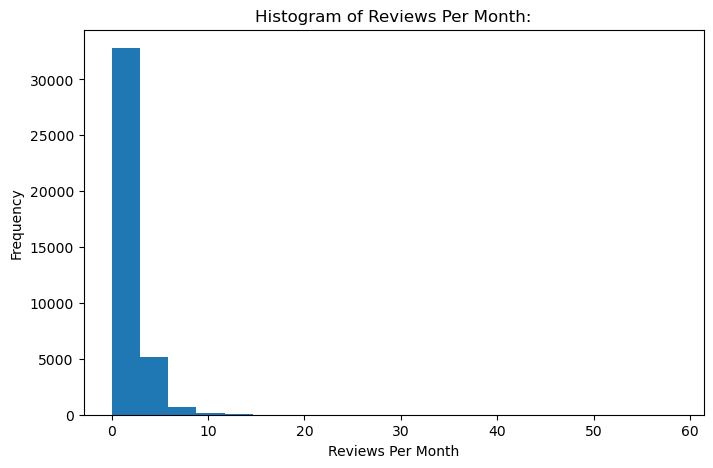

In [15]:
#Plot histogram for reviews per month
plt.figure(figsize=(8,5))
plt.hist(df['reviews_per_month'].dropna(), bins=20)
plt.title('Histogram of Reviews Per Month:')
plt.xlabel('Reviews Per Month')
plt.ylabel('Frequency')
plt.show()

<Figure size 1000x600 with 0 Axes>

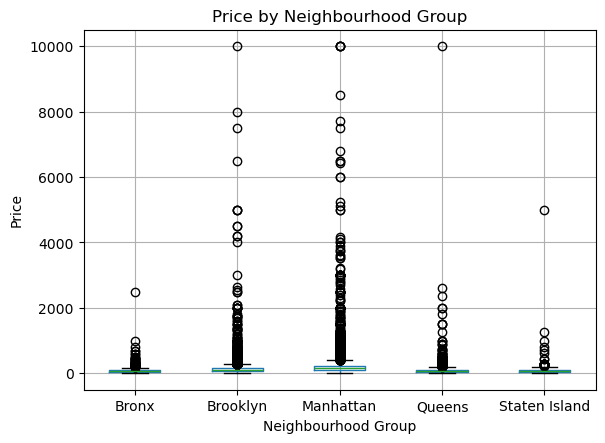

In [16]:
#boxplot of price by neighbourhood group
plt.figure(figsize=(10,6))
df.boxplot(column='price', by='neighbourhood_group')
plt.title('Price by Neighbourhood Group')
plt.suptitle('')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Price')
plt.show()

In [17]:
#neighbourhood with highest average price
avg_price = df.groupby('neighbourhood_group')['price'].mean()
highest_price_neighbourhood = avg_price.idxmax()
print("Neighborhood with Highest Average Price:")
print(highest_price_neighbourhood)
print("\nAverage Prices:")
print(avg_price)

Neighborhood with Highest Average Price:
Manhattan

Average Prices:
neighbourhood_group
Bronx             87.496792
Brooklyn         124.383207
Manhattan        196.875814
Queens            99.517649
Staten Island    114.812332
Name: price, dtype: float64


In [18]:
#Top 5 neighborhoods by average reviews_per_month
top_reviews = (
    df.groupby('neighbourhood')['reviews_per_month']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)
print("\nTop 5 Neighborhoods by Average Reviews Per Month:")
print(top_reviews)


Top 5 Neighborhoods by Average Reviews Per Month:
neighbourhood
New Dorp Beach         5.500000
East Elmhurst          4.822982
Springfield Gardens    4.455250
Silver Lake            4.340000
Rosebank               3.812857
Name: reviews_per_month, dtype: float64


In [19]:
#Create new column 'high_price'
df['high_price'] = df['price'] > 500
print("\nDataset with New Column 'high_price':")
print(df[['price', 'high_price']].head())


Dataset with New Column 'high_price':
   price  high_price
0    149       False
1    225       False
2    150       False
3     89       False
4     80       False


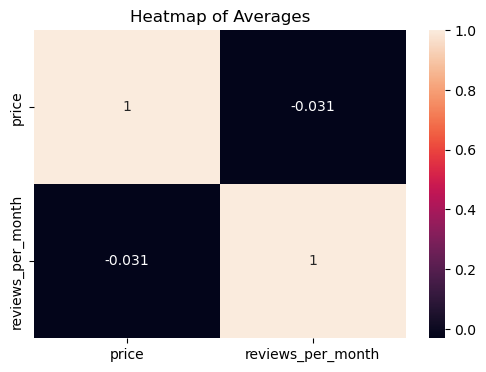

In [20]:
#Heatmap Visualization
corr = df[['price', 'reviews_per_month']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.title('Heatmap of Averages')
plt.show()